# Day 6: Advanced Analytics & Risk Metrics (Mutual Fund Capstone)

This notebook presents advanced risk analytics, investor behavioral models, and portfolio concentration metrics. 

### Key Analytics Performed:
1. **Value at Risk (VaR) & Conditional VaR (CVaR):** 95% confidence historical downside risk metrics.
2. **Rolling 90-Day Sharpe Ratios:** Time-varying risk-adjusted performance of the top 5 funds.
3. **Investor Cohort Analysis:** Behavioral analysis comparing investors who joined in 2024 vs. 2025.
4. **SIP Continuity & At-Risk Analysis:** Identifying accounts showing signs of potential default (average transaction gaps > 35 days).
5. **Sector Concentration (HHI):** Portfolio diversification check using the Herfindahl-Hirschman Index on equity sectors.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Directories
DATA_DIR = "../data/processed"
FIGURES_DIR = "../reports/figures"
DB_PATH = "../db/bluestock_mf.db"

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("[+] Environment initialized.")


[+] Environment initialized.


## 1. Downside Risk: Historical Value at Risk (VaR) & CVaR (95%)
Value at Risk (VaR) represents the worst-case loss expected at a 95% confidence level over a one-day horizon. Conditional VaR (CVaR) measures the average loss on days where the return drops below the 95% VaR threshold.


In [2]:
df_var = pd.read_csv(os.path.join(DATA_DIR, "var_cvar_report.csv"))
df_var_sorted = df_var.sort_values(by="var_95_pct").reset_index(drop=True)

print("--- TOP 10 RISKIEST FUNDS (Highest negative VaR) ---")
display(df_var_sorted.head(10))

print("\n--- TOP 10 SAFEST FUNDS (Lowest negative VaR) ---")
display(df_var_sorted.tail(10))


--- TOP 10 RISKIEST FUNDS (Highest negative VaR) ---


,amfi_code,scheme_name,var_95_pct,cvar_95_pct
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
1,119095,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
2,101207,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
3,118634,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
4,119598,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526
5,149324,DSP Small Cap Fund - Regular - Growth,-2.348307,-3.103625
6,102886,UTI Mid Cap Fund - Regular - Growth,-1.922028,-2.325086
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
8,120505,ICICI Pru Midcap Fund - Regular - Growth,-1.889179,-2.434207
9,119094,Axis Midcap Fund - Regular - Growth,-1.848028,-2.426006



--- TOP 10 SAFEST FUNDS (Lowest negative VaR) ---


,amfi_code,scheme_name,var_95_pct,cvar_95_pct
30,102885,UTI Nifty 50 Index Fund - Regular - Growth,-1.261263,-1.549041
31,118635,Nippon India ETF Nifty 50 BeES,-1.255370,-1.617696
32,119092,Axis Bluechip Fund - Regular - Growth,-0.899503,-2.910626
33,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.864498,-2.382242
34,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.393828,-0.501369
35,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.380415,-0.491892
36,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.379325,-0.499376
37,120844,Kotak Liquid Fund - Regular - Growth,-0.028479,-0.041100
38,101208,ABSL Liquid Fund - Regular - Growth,-0.026866,-0.042208
39,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.022157,-0.037258


## 2. Rolling 90-Day Sharpe Ratio
Below is the pre-computed rolling 90-day Sharpe ratio timeseries chart for the top 5 performing funds in our universe. This showcases how the risk-adjusted return profile varies over time.


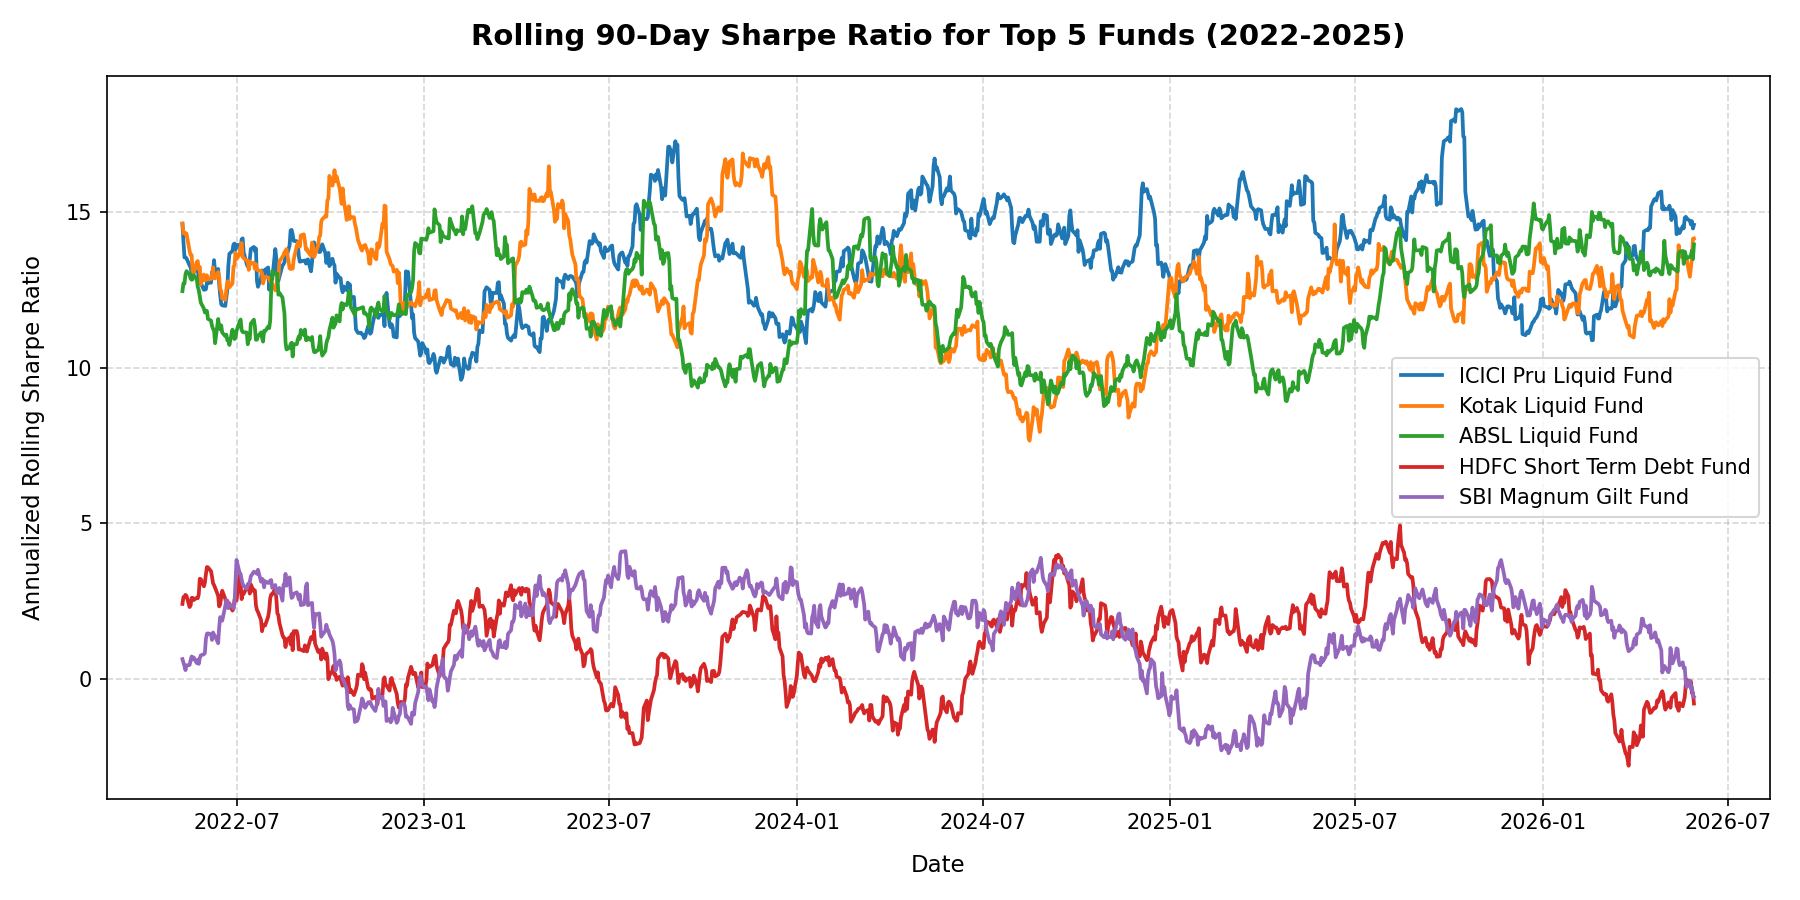

In [3]:
from IPython.display import Image, display as ipy_display
chart_path = os.path.join(FIGURES_DIR, "rolling_sharpe_chart.png")
if os.path.exists(chart_path):
    ipy_display(Image(filename=chart_path))
else:
    print("[-] Rolling Sharpe chart not found. Run advanced_analytics.py first.")


## 3. Investor Cohort Analysis (2024 vs. 2025)
Grouping investors by their acquisition year (first transaction year) allows us to analyze changes in behavioral patterns, transaction sizing, and asset preferences.


In [4]:
df_cohort = pd.read_csv(os.path.join(DATA_DIR, "cohort_analysis.csv"))
print("--- COHORT BEHAVIOR ANALYSIS ---")
display(df_cohort)


--- COHORT BEHAVIOR ANALYSIS ---


,cohort_year,investor_count,avg_sip_size_inr,total_invested_inr,top_preferred_fund,top_fund_transaction_count
0,2024,4803,10996.885825,2.258062e+09,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,197,13505.209581,1.899264e+07,SBI Small Cap Fund - Direct Plan - Growth,12


## 4. SIP Continuity & At-Risk Accounts
For clients with 6 or more monthly transactions, we calculate the average gap in days. Gaps consistently exceeding 35 days indicate a high probability of SIP default or halt.


In [5]:
df_sip = pd.read_csv(os.path.join(DATA_DIR, "sip_continuity.csv"))
df_at_risk = df_sip[df_sip['is_at_risk'] == 1].reset_index(drop=True)

print(f"Total active SIP clients analyzed: {len(df_sip)}")
print(f"Total clients flagged as 'At Risk' (gap > 35 days): {len(df_at_risk)}")

print("\n--- SAMPLE OF AT-RISK SIP ACCOUNTS ---")
display(df_at_risk.head(10))


Total active SIP clients analyzed: 1362
Total clients flagged as 'At Risk' (gap > 35 days): 1332

--- SAMPLE OF AT-RISK SIP ACCOUNTS ---


,investor_id,sip_count,average_gap_days,is_at_risk
0,INV000004,6,85.400000,1
1,INV000008,6,70.400000,1
2,INV000010,6,64.800000,1
3,INV000011,7,40.166667,1
4,INV000012,8,57.000000,1
5,INV000013,7,55.333333,1
6,INV000014,7,75.333333,1
7,INV000023,8,58.571429,1
8,INV000028,6,93.600000,1
9,INV000029,7,60.666667,1


## 5. Sector Concentration Analysis (HHI)
The Herfindahl-Hirschman Index (HHI) evaluates the diversification level of equity fund holdings. 
- **HHI < 1500:** Well-diversified sector exposure.
- **HHI 1500 - 2500:** Moderate sector concentration.
- **HHI > 2500:** High sector concentration (focused thematic or sector funds).


--- HIGHLY CONCENTRATED FUNDS (Top 5) ---


,amfi_code,scheme_name,hhi_score
11,119092,Axis Bluechip Fund - Regular - Growth,2968.284527
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2550.939674
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2531.550000
6,102887,UTI Flexi Cap Fund - Regular - Growth,2513.322810
32,149323,DSP Midcap Fund - Regular - Growth,2410.766400



--- WELL DIVERSIFIED FUNDS (Top 5) ---


,amfi_code,scheme_name,hhi_score
5,102886,UTI Mid Cap Fund - Regular - Growth,1240.698630
25,120843,Kotak Flexicap Fund - Regular - Growth,1362.061600
15,119551,SBI Bluechip Fund - Regular Plan - Growth,1424.910400
14,119095,Axis Small Cap Fund - Regular - Growth,1596.142112
9,118634,Nippon India Small Cap Fund - Regular - Growth,1602.992400


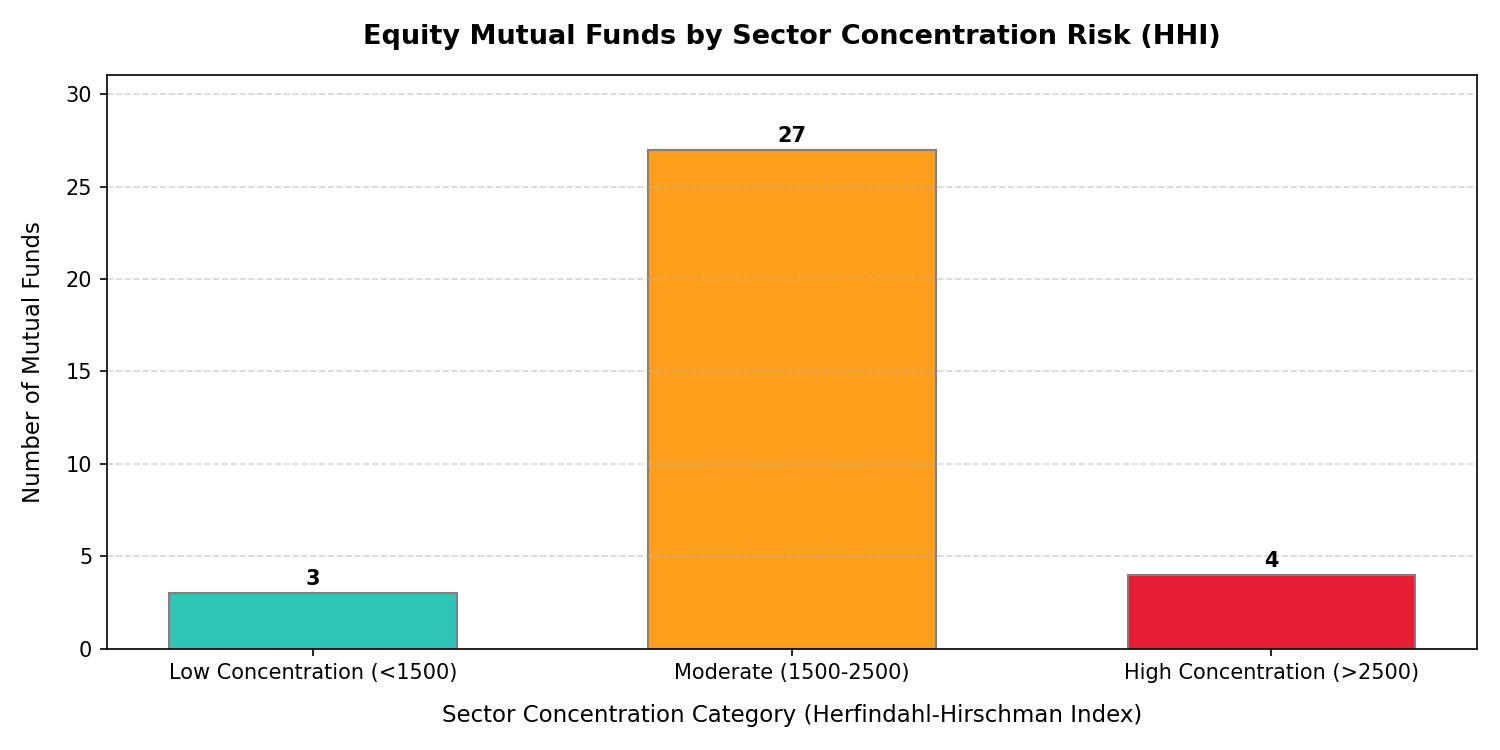

In [6]:
df_hhi = pd.read_csv(os.path.join(DATA_DIR, "sector_hhi.csv"))
print("--- HIGHLY CONCENTRATED FUNDS (Top 5) ---")
display(df_hhi.sort_values('hhi_score', ascending=False).head(5))

print("\n--- WELL DIVERSIFIED FUNDS (Top 5) ---")
display(df_hhi.sort_values('hhi_score').head(5))

chart_path_hhi = os.path.join(FIGURES_DIR, "sector_hhi_chart.png")
if os.path.exists(chart_path_hhi):
    ipy_display(Image(filename=chart_path_hhi))
